In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path('..').resolve() if (Path('..') / 'data').exists() else Path('.').resolve()
DATA_DIR = REPO_ROOT / 'data'
FIG_DIR = REPO_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

train_features = pd.read_csv(DATA_DIR / 'dengue_features_train.csv')
train_labels = pd.read_csv(DATA_DIR / 'dengue_labels_train.csv')

train_data = pd.merge(train_features, train_labels, on=['city', 'year', 'weekofyear'])

# Split by city
sj_data = train_data[train_data['city'] == 'sj'].copy()
iq_data = train_data[train_data['city'] == 'iq'].copy()



In [3]:
def add_advanced_features(df):
    df = df.copy()
    
    # Use the correct precipitation column name based on your dataset
    precip_col = 'precipitation_amt_mm' # Double check if this is the exact name in df.columns
    
    if precip_col in df.columns:
        df['precip_sum_4w'] = df[precip_col].rolling(window=4, min_periods=1).sum()
    else:
        print(f"Warning: Column '{precip_col}' not found.")
        
    df['temp_amplitude'] = df['station_max_temp_c'] - df['station_min_temp_c']
    df['heat_humidity_idx'] = (df['reanalysis_avg_temp_k'] / 100) * (df['reanalysis_relative_humidity_percent'] / 100)
    df['week_sin'] = np.sin(2 * np.pi * df['weekofyear'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['weekofyear'] / 52)
    df['temp_change_1w'] = df['station_avg_temp_c'].diff(periods=1).fillna(0)
    return df

In [4]:
def compute_lag_correlations(df, target='total_cases', max_lag=10):
    corrs = {}
    features = [
        'station_avg_temp_c', 
        'precipitation_amt_mm', 
        'reanalysis_relative_humidity_percent' 
    ]
    
    for feat in features:
        # Guard against missing columns (KeyError)
        if feat not in df.columns:
            print(f"Warning: Column '{feat}' not found in dataframe. Skipping.")
            continue
            
        feat_corrs = []
        for lag in range(max_lag + 1):
            # Shift feature forward by lag weeks
            shifted_feat = df[feat].shift(lag)
            corr = df[target].corr(shifted_feat)
            feat_corrs.append(corr)
        corrs[feat] = feat_corrs
        
    return pd.DataFrame(corrs)

print("Lag correlations for San Juan:")
print(compute_lag_correlations(sj_data))

print("\nLag correlations for Iquitos (IQ):")
print(compute_lag_correlations(iq_data))


Lag correlations for San Juan:
    station_avg_temp_c  precipitation_amt_mm  \
0             0.196617              0.060211   
1             0.222738              0.076733   
2             0.249776              0.083663   
3             0.281828              0.076070   
4             0.306580              0.071535   
5             0.330192              0.072011   
6             0.344708              0.073053   
7             0.356195              0.064996   
8             0.364173              0.064101   
9             0.368082              0.058105   
10            0.368997              0.051298   

    reanalysis_relative_humidity_percent  
0                               0.144045  
1                               0.152749  
2                               0.164791  
3                               0.166938  
4                               0.163962  
5                               0.160017  
6                               0.158623  
7                               0.154514  
8    

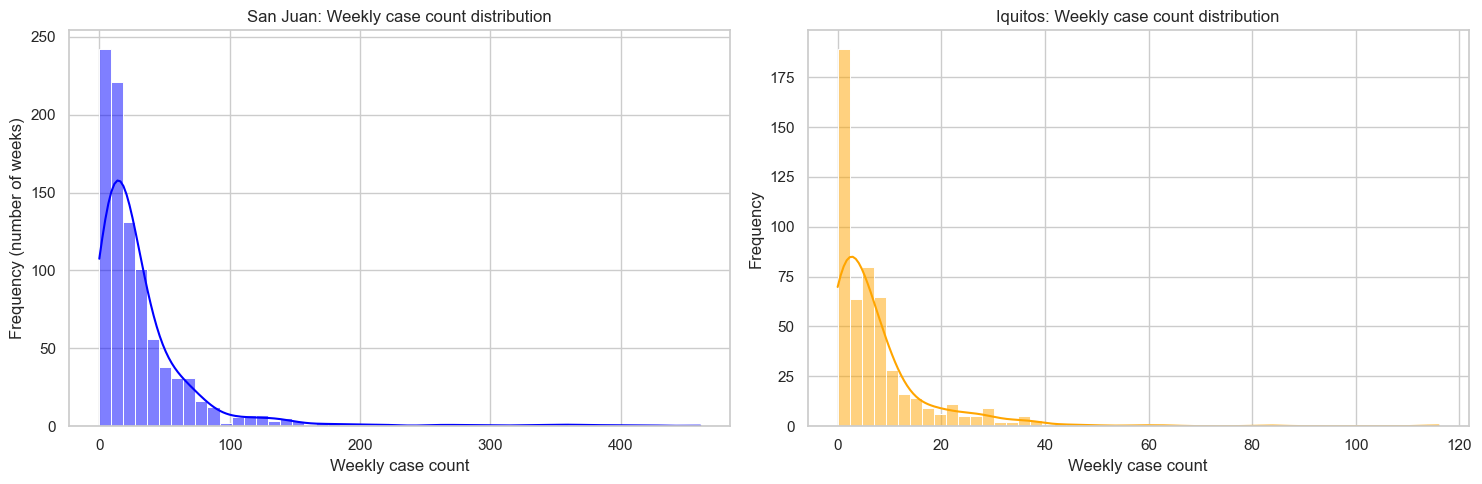

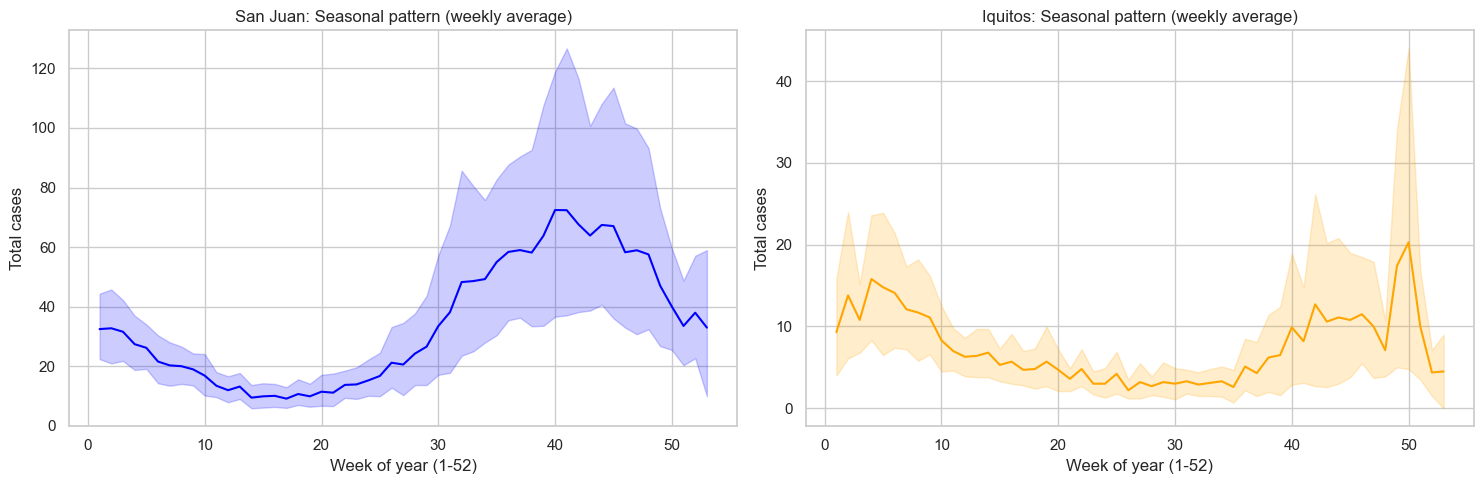

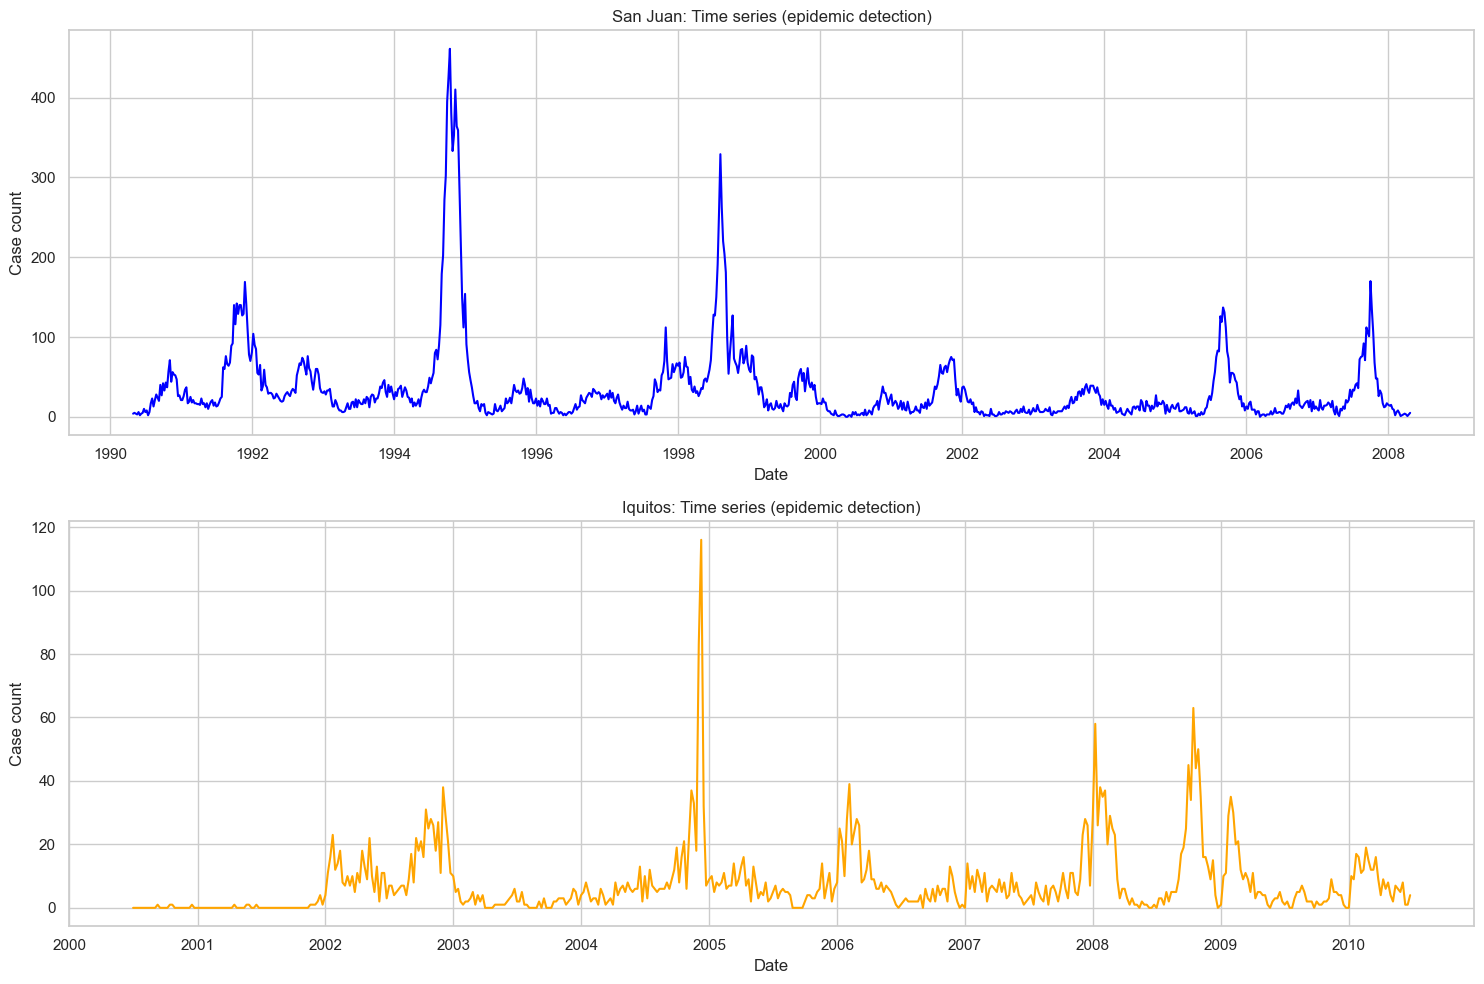

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- SAFE DATE CREATION ---
def ensure_datetime(df):
    df = df.copy()
    if 'week_start_date' in df.columns:
        # If column exists, convert to proper format
        df['week_start_date'] = pd.to_datetime(df['week_start_date'])
    elif 'year' in df.columns and 'weekofyear' in df.columns:
        # If column missing, recreate synthetic date for plots
        # (Jan 1 of year + week offset)
        df['week_start_date'] = pd.to_datetime(df['year'].astype(str), format='%Y') + pd.to_timedelta(df['weekofyear'] * 7, unit='days')
        print("Recreated 'week_start_date' from year and week.")
    else:
        # Fallback: use index if no date/year/week
        df['week_start_date'] = df.reset_index().index
    return df

sj_data_plot = ensure_datetime(sj_data)
iq_data_plot = ensure_datetime(iq_data)

# Plot style
sns.set_theme(style="whitegrid")

# --- 1. WEEKLY CASE COUNT DISTRIBUTION ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(sj_data_plot['total_cases'], bins=50, ax=axes[0], color='blue', kde=True)
axes[0].set_title('San Juan: Weekly case count distribution')
axes[0].set_xlabel('Weekly case count')
axes[0].set_ylabel('Frequency (number of weeks)')

sns.histplot(iq_data_plot['total_cases'], bins=50, ax=axes[1], color='orange', kde=True)
axes[1].set_title('Iquitos: Weekly case count distribution')
axes[1].set_xlabel('Weekly case count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# --- 2. SEASONAL PATTERNS ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=sj_data_plot, x='weekofyear', y='total_cases', ax=axes[0], color='blue')
axes[0].set_title('San Juan: Seasonal pattern (weekly average)')
axes[0].set_xlabel('Week of year (1-52)')
axes[0].set_ylabel("Total cases")

sns.lineplot(data=iq_data_plot, x='weekofyear', y='total_cases', ax=axes[1], color='orange')
axes[1].set_title('Iquitos: Seasonal pattern (weekly average)')
axes[1].set_xlabel('Week of year (1-52)')
axes[1].set_ylabel("Total cases")

plt.tight_layout()
plt.show()

# --- 3. EPIDEMIC YEARS (TIME SERIES) ---
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

sns.lineplot(data=sj_data_plot, x='week_start_date', y='total_cases', ax=axes[0], color='blue')
axes[0].set_title('San Juan: Time series (epidemic detection)')
axes[0].set_ylabel('Case count')
axes[0].set_xlabel('Date')

sns.lineplot(data=iq_data_plot, x='week_start_date', y='total_cases', ax=axes[1], color='orange')
axes[1].set_title('Iquitos: Time series (epidemic detection)')
axes[1].set_ylabel('Case count')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()


Case count distribution:

Strong right skew: most weeks are quiet (San Juan typically 0–50 cases, Iquitos 0–10). The long right tail is rare weeks with very high case counts.

Seasonal pattern:

San Juan: One broad seasonal wave. Case count rises around week 25, peaks in autumn (weeks 35–45), then declines.

Iquitos: Different pattern—mid-year dip (weeks 15–35), then a large surge around the year boundary (weeks 45–10).

Time series:

Peaks include San Juan in 1994 (~500 cases) and Iquitos at end of 2004 (100+). These are outliers; wide bands on seasonal plots come from the same calendar week having very different counts across years.


In [9]:
# 1. Convert text column to proper date format
sj_data['week_start_date'] = pd.to_datetime(sj_data['week_start_date'])
iq_data['week_start_date'] = pd.to_datetime(iq_data['week_start_date'])

# 2. Print time coverage
print("=== 1. TIME COVERAGE ===")
print(f"San Juan (SJ): From {sj_data['week_start_date'].min().date()} to {sj_data['week_start_date'].max().date()} (Number of weeks: {len(sj_data)})")
print(f"Iquitos (IQ):  From {iq_data['week_start_date'].min().date()} to {iq_data['week_start_date'].max().date()} (Number of weeks: {len(iq_data)})\n")


=== 1. TIME COVERAGE ===
San Juan (SJ): From 1990-04-30 to 2008-04-22 (Number of weeks: 936)
Iquitos (IQ):  From 2000-07-01 to 2010-06-25 (Number of weeks: 520)



In [10]:
# Exclude ID columns and target
features = [col for col in sj_data.columns if col not in ['city', 'year', 'weekofyear', 'week_start_date', 'total_cases']]

missing_sj = sj_data[features].isnull().sum().sort_values(ascending=False)
missing_iq = iq_data[features].isnull().sum().sort_values(ascending=False)

print("San Juan (missing value count):")
print(missing_sj.head().round(2).astype(str) )
print("\nIquitos (missing value count):")
print(missing_iq.head().round(2).astype(str) )

San Juan (missing value count):
ndvi_ne                         191
ndvi_nw                          49
ndvi_se                          19
ndvi_sw                          19
reanalysis_sat_precip_amt_mm      9
dtype: object

Iquitos (missing value count):
station_diur_temp_rng_c    37
station_avg_temp_c         37
station_precip_mm          16
station_max_temp_c         14
station_min_temp_c          8
dtype: object


In [11]:
# Find best lag (0-15 weeks) per feature
def find_best_lags(df, features_list, target='total_cases', max_lag=15):
    best_lags = []
    
    for feat in features_list:
        corrs = []
        for lag in range(max_lag + 1):
            shifted = df[feat].shift(lag)
            corr = df[target].corr(shifted)
            corrs.append(corr)
            
        # Pick lag with highest absolute correlation
        corrs_abs = [abs(c) if not np.isnan(c) else 0 for c in corrs]
        best_lag = np.argmax(corrs_abs)
        best_corr = corrs[best_lag]
        
        best_lags.append({
            'Feature': feat,
            'Optimal Lag (weeks)': best_lag,
            'Correlation': round(best_corr, 3)
        })
        
    # Build DataFrame sorted by correlation strength
    result_df = pd.DataFrame(best_lags)
    result_df['Abs_Correlation'] = result_df['Correlation'].abs()
    result_df = result_df.sort_values(by='Abs_Correlation', ascending=False).drop('Abs_Correlation', axis=1)
    return result_df

best_lags_sj = find_best_lags(sj_data, features)
best_lags_iq = find_best_lags(iq_data, features)

print("TOP 10 features for SAN JUAN (sorted by correlation strength):")
print(best_lags_sj.head(10).to_string(index=False))
print("\nTOP 10 features for IQUITOS (sorted by correlation strength):")
print(best_lags_iq.head(10).to_string(index=False))


TOP 10 features for SAN JUAN (sorted by correlation strength):
                              Feature  Optimal Lag (weeks)  Correlation
                   station_avg_temp_c                   10        0.369
                   station_min_temp_c                   10        0.362
                   station_max_temp_c                   11        0.315
            reanalysis_min_air_temp_k                    8        0.303
          reanalysis_dew_point_temp_k                    8        0.302
reanalysis_specific_humidity_g_per_kg                    8        0.302
                reanalysis_air_temp_k                    8        0.298
                reanalysis_avg_temp_k                    8        0.295
            reanalysis_max_air_temp_k                    7        0.295
 reanalysis_relative_humidity_percent                    3        0.167

TOP 10 features for IQUITOS (sorted by correlation strength):
                              Feature  Optimal Lag (weeks)  Correlation
reanalysis

In [12]:
def prepare_model_input(city_data, best_lags_df, n_top_features=10):
    """
    Build model dataframe with top features at optimal lags.
    """
    # Start from base columns
    df_model = city_data[['total_cases', 'weekofyear']].copy()
    df_model['cases_moving_avg'] = city_data['total_cases'].shift(1).rolling(window=4).mean()  # Extra feature: 4-week moving average

    # Select top N features from lag analysis
    top_feats = best_lags_df.head(n_top_features)
    
    for _, row in top_feats.iterrows():
        feat = row['Feature']
        lag = int(row['Optimal Lag (weeks)'])
        # Add lagged feature to model frame
        df_model[f"{feat}_lag{lag}"] = city_data[feat].shift(lag)
    
    # Drop NaN rows from shifts and reset index
    return df_model.dropna().reset_index(drop=True)


In [13]:
import os
import optuna

# macOS + Jupyter: joblib n_jobs=-1 with XGBoost/LightGBM can SIGSEGV → N_JOBS=1.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

N_JOBS = 1  # safe in notebook on Mac; on Linux you can use -1
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV

def build_xgb(params):
    """XGBoost z parametrami po strojeniu (Optuna / RandomizedSearch)."""
    return XGBRegressor(**params, objective='reg:absoluteerror', random_state=42, n_jobs=N_JOBS)

def _mae_on_test(model, X_test, y_test):
    return mean_absolute_error(y_test, np.expm1(model.predict(X_test)))

def _optuna_objective(trial, model_name, X_train, y_train, tscv):
    if model_name == 'RandomForest':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'max_depth': trial.suggest_int('max_depth', 5, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 1.0]),
        }
        model = RandomForestRegressor(**param, random_state=42)
    elif model_name == 'XGBoost':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        }
        model = build_xgb(param)
    else:
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        }
        model = LGBMRegressor(**param, objective='regression_l1', random_state=42, verbose=-1)

    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr)
        scores.append(mean_absolute_error(y_val, model.predict(X_val)))
    return float(np.mean(scores))

def _randomized_search_models(X_train, y_train_log, X_test, y_test, tscv):
    """Phase 1: RandomizedSearchCV tuning."""
    searches = {
        'RandomForest': (
            RandomForestRegressor(random_state=42, n_jobs=N_JOBS),
            {
                'n_estimators': [100, 200, 300],
                'max_depth': [5, 10, 15, None],
                'min_samples_split': [2, 5, 10],
                'max_features': ['sqrt', 'log2', 1.0],
            },
            10,
        ),
        'XGBoost': (
            XGBRegressor(objective='reg:absoluteerror', random_state=42, n_jobs=N_JOBS),
            {
                'n_estimators': [100, 300, 500],
                'max_depth': [3, 4, 5],
                'learning_rate': [0.01, 0.05, 0.1],
                'subsample': [0.7, 0.8, 1.0],
            },
            20,
        ),
        'LightGBM': (
            LGBMRegressor(objective='regression_l1', random_state=42, verbose=-1, n_jobs=N_JOBS),
            {
                'n_estimators': [100, 300, 500],
                'max_depth': [3, 5, 7, -1],
                'learning_rate': [0.01, 0.05, 0.1],
                'subsample': [0.7, 0.8, 1.0],
            },
            20,
        ),
    }
    mae = {}
    for name, (estimator, grid, n_iter) in searches.items():
        print(f"  RandomizedSearch: {name}...")
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=grid,
            n_iter=n_iter,
            cv=tscv,
            scoring='neg_mean_absolute_error',
            random_state=42,
            n_jobs=N_JOBS,
        )
        search.fit(X_train, y_train_log)
        mae[name] = _mae_on_test(search.best_estimator_, X_test, y_test)
        print(f"    MAE test: {mae[name]:.4f} | params: {search.best_params_}")
    return mae

def _optuna_tune_models(X_train, y_train_log, X_test, y_test, tscv, n_trials=50):
    """Phase 2: Optuna tuning + final train on 80% data."""
    best_models = {}
    best_hyperparams = {}
    mae = {}

    for model_name in ['RandomForest', 'XGBoost', 'LightGBM']:
        print(f"  Optuna: {model_name} ({n_trials} trials)...")
        study = optuna.create_study(direction='minimize')
        study.optimize(
            lambda trial: _optuna_objective(trial, model_name, X_train, y_train_log, tscv),
            n_trials=n_trials,
            show_progress_bar=False,
        )
        best_hyperparams[model_name] = study.best_params
        print(f"    Best parameters: {study.best_params}")

        if model_name == 'RandomForest':
            final_model = RandomForestRegressor(**study.best_params, random_state=42)
        elif model_name == 'XGBoost':
            final_model = build_xgb(study.best_params)
        else:
            final_model = LGBMRegressor(**study.best_params, objective='regression_l1', random_state=42, verbose=-1)

        final_model.fit(X_train, y_train_log)
        best_models[model_name] = final_model
        mae[model_name] = _mae_on_test(final_model, X_test, y_test)
        print(f"    Test MAE (after final training): {mae[model_name]:.4f}")

    return best_models, best_hyperparams, mae

def compare_xgb_optimization_methods(X_train, y_train, X_test, y_test):
    """Phase 3: compare Grid / Random / Optuna for XGBoost."""
    param_grid = {
        'n_estimators': [100, 300],
        'max_depth': [3, 5],
        'learning_rate': [0.01, 0.1],
    }
    y_train_log = np.log1p(y_train)
    tscv = TimeSeriesSplit(n_splits=3)
    rows = []

    grid = GridSearchCV(
        XGBRegressor(objective='reg:absoluteerror', random_state=42, n_jobs=N_JOBS),
        param_grid, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=N_JOBS,
    )
    grid.fit(X_train, y_train_log)
    rows.append({'Method': 'GridSearch', 'MAE': _mae_on_test(grid.best_estimator_, X_test, y_test)})

    rand = RandomizedSearchCV(
        XGBRegressor(objective='reg:absoluteerror', random_state=42, n_jobs=N_JOBS),
        param_grid, n_iter=5, cv=tscv, scoring='neg_mean_absolute_error',
        n_jobs=N_JOBS, random_state=42,
    )
    rand.fit(X_train, y_train_log)
    rows.append({'Method': 'RandomSearch', 'MAE': _mae_on_test(rand.best_estimator_, X_test, y_test)})

    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        }
        model = build_xgb(param)
        scores = []
        for train_idx, val_idx in tscv.split(X_train):
            model.fit(X_train.iloc[train_idx], y_train_log.iloc[train_idx])
            preds = model.predict(X_train.iloc[val_idx])
            scores.append(mean_absolute_error(y_train_log.iloc[val_idx], preds))
        return float(np.mean(scores))

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=20, show_progress_bar=False)
    best_optuna = build_xgb(study.best_params)
    best_optuna.fit(X_train, y_train_log)
    rows.append({'Method': 'Optuna', 'MAE': _mae_on_test(best_optuna, X_test, y_test)})

    return pd.DataFrame(rows).sort_values(by='MAE')

def run_post_analysis(models, X_train, y_train, X_test, y_test, city_name):
    weather_cols = [c for c in X_train.columns if any(k in c for k in ('precip', 'temp', 'humidity'))]
    best_model_name = min(models, key=lambda k: _mae_on_test(models[k], X_test, y_test))
    best_model = models[best_model_name]

    print(f"\n--- Best model analysis ({best_model_name}) — {city_name} ---")
    pd.Series(best_model.feature_importances_, index=X_train.columns).nlargest(10).plot(
        kind='barh', title=f"Top 10 features: {best_model_name}"
    )
    plt.show()

    if not weather_cols:
        print("No weather columns available for ablation.")
        return

    model_no = type(best_model)(**best_model.get_params())
    model_no.fit(X_train.drop(columns=weather_cols), y_train)
    mae_with = _mae_on_test(best_model, X_test, y_test)
    mae_no = _mae_on_test(
        model_no,
        X_test.drop(columns=weather_cols),
        y_test,
    )
    print(f"MAE with weather: {mae_with:.4f}")
    print(f"MAE without weather: {mae_no:.4f}")
    print(f"Weather improves MAE by: {mae_no - mae_with:.4f}")

def train_and_tune_city(df_input, city_name, optuna_trials=50):
    """Pipeline: RandomizedSearch -> Optuna -> method comparison -> analysis."""
    print(f"\n{'=' * 64}\n  HYPERPARAMETER TUNING AND MODEL EVALUATION: {city_name}\n{'=' * 64}")

    split = int(len(df_input) * 0.8)
    train, test = df_input.iloc[:split], df_input.iloc[split:]
    X_train = train.drop('total_cases', axis=1)
    y_train_log = np.log1p(train['total_cases'])
    X_test = test.drop('total_cases', axis=1)
    y_test = test['total_cases']
    y_train_raw = train['total_cases']
    tscv = TimeSeriesSplit(n_splits=3)

    print("\n[1/3] RandomizedSearchCV")
    rs_mae = _randomized_search_models(X_train, y_train_log, X_test, y_test, tscv)
    print(pd.Series(rs_mae).sort_values().to_frame('MAE_test'))

    print("\n[2/3] Optuna + final training")
    models, params, optuna_mae = _optuna_tune_models(
        X_train, y_train_log, X_test, y_test, tscv, n_trials=optuna_trials,
    )
    print("\nMAE summary (Optuna, 20% test):")
    print(pd.Series(optuna_mae).sort_values())

    print("\n[3/3] Comparing optimization methods (XGBoost)")
    print(compare_xgb_optimization_methods(X_train, y_train_raw, X_test, y_test).to_string(index=False))

    run_post_analysis(models, X_train, y_train_log, X_test, y_test, city_name)

    return {
        'models': models,
        'params': params,
        'X_train': X_train,
        'y_train': y_train_log,
        'X_test': X_test,
        'y_test': y_test,
    }


SARIMA excluded—it performed worst in earlier checks.




  HYPERPARAMETER TUNING AND MODEL EVALUATION: SAN JUAN

[1/3] RandomizedSearchCV
  RandomizedSearch: RandomForest...
    MAE test: 9.0420 | params: {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 1.0, 'max_depth': 15}
  RandomizedSearch: XGBoost...
    MAE test: 8.4478 | params: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05}
  RandomizedSearch: LightGBM...


[I 2026-05-31 20:38:40,445] A new study created in memory with name: no-name-7ed2d0b6-781f-4508-bc5b-e5c7352bf8e2


    MAE test: 10.2321 | params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1}
               MAE_test
XGBoost        8.447766
RandomForest   9.041961
LightGBM      10.232122

[2/3] Optuna + final training
  Optuna: RandomForest (50 trials)...


[I 2026-05-31 20:38:43,444] Trial 0 finished with value: 0.39699518546680274 and parameters: {'n_estimators': 230, 'max_depth': 12, 'min_samples_split': 6, 'max_features': 1.0}. Best is trial 0 with value: 0.39699518546680274.
[I 2026-05-31 20:38:44,729] Trial 1 finished with value: 0.5410289804637678 and parameters: {'n_estimators': 185, 'max_depth': 6, 'min_samples_split': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.39699518546680274.
[I 2026-05-31 20:38:46,825] Trial 2 finished with value: 0.39498354868295404 and parameters: {'n_estimators': 176, 'max_depth': 7, 'min_samples_split': 8, 'max_features': 1.0}. Best is trial 2 with value: 0.39498354868295404.
[I 2026-05-31 20:38:49,167] Trial 3 finished with value: 0.39686737293894797 and parameters: {'n_estimators': 222, 'max_depth': 9, 'min_samples_split': 7, 'max_features': 1.0}. Best is trial 2 with value: 0.39498354868295404.
[I 2026-05-31 20:38:50,138] Trial 4 finished with value: 0.5188944766018437 and parameters: {

    Best parameters: {'n_estimators': 271, 'max_depth': 5, 'min_samples_split': 4, 'max_features': 1.0}


...

    Test MAE (after final training): 8.7037
  Optuna: LightGBM (50 trials)...


[I 2026-05-31 20:42:32,083] Trial 0 finished with value: 0.44163960810914743 and parameters: {'n_estimators': 405, 'max_depth': 7, 'learning_rate': 0.01103385561359789, 'subsample': 0.6514372724919542}. Best is trial 0 with value: 0.44163960810914743.
[I 2026-05-31 20:42:32,407] Trial 1 finished with value: 0.42816615806332553 and parameters: {'n_estimators': 346, 'max_depth': 7, 'learning_rate': 0.08521217372661272, 'subsample': 0.9873980911149893}. Best is trial 1 with value: 0.42816615806332553.
[I 2026-05-31 20:42:32,543] Trial 2 finished with value: 0.43118904342001513 and parameters: {'n_estimators': 184, 'max_depth': 4, 'learning_rate': 0.09672292574816807, 'subsample': 0.8529493049542256}. Best is trial 1 with value: 0.42816615806332553.
[I 2026-05-31 20:42:32,905] Trial 3 finished with value: 0.44283859482151094 and parameters: {'n_estimators': 408, 'max_depth': 6, 'learning_rate': 0.01060794561549136, 'subsample': 0.7436757309229747}. Best is trial 1 with value: 0.42816615806

    Best parameters: {'n_estimators': 280, 'max_depth': 7, 'learning_rate': 0.08968885369459399, 'subsample': 0.9763815659768377}
    Test MAE (after final training): 9.7444

MAE summary (Optuna, 20% test):
XGBoost         8.703698
RandomForest    9.313906
LightGBM        9.744357
dtype: float64

[3/3] Comparing optimization methods (XGBoost)


[I 2026-05-31 20:42:55,084] A new study created in memory with name: no-name-edf775d0-00e2-4591-b794-bbb4c633465c
[I 2026-05-31 20:42:55,571] Trial 0 finished with value: 0.4687388352658212 and parameters: {'n_estimators': 156, 'max_depth': 4, 'learning_rate': 0.014446427145769259}. Best is trial 0 with value: 0.4687388352658212.
[I 2026-05-31 20:42:55,872] Trial 1 finished with value: 0.4278740313562377 and parameters: {'n_estimators': 139, 'max_depth': 3, 'learning_rate': 0.03331402530764225}. Best is trial 1 with value: 0.4278740313562377.
[I 2026-05-31 20:42:56,344] Trial 2 finished with value: 0.4278800657790853 and parameters: {'n_estimators': 102, 'max_depth': 5, 'learning_rate': 0.09878958221507546}. Best is trial 1 with value: 0.4278740313562377.
[I 2026-05-31 20:42:57,229] Trial 3 finished with value: 0.4189722872464043 and parameters: {'n_estimators': 494, 'max_depth': 3, 'learning_rate': 0.013159735563952956}. Best is trial 3 with value: 0.4189722872464043.
[I 2026-05-31 20

      Method      MAE
      Optuna 8.363265
  GridSearch 8.835278
RandomSearch 8.835278

--- Best model analysis (XGBoost) — SAN JUAN ---


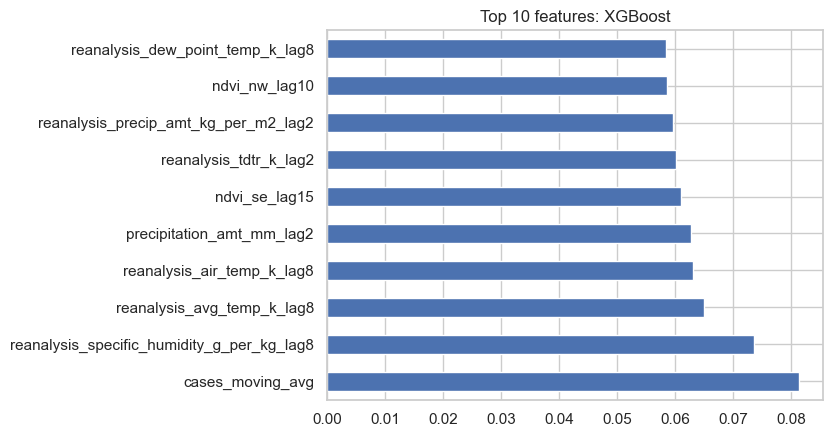

MAE with weather: 8.7037
MAE without weather: 8.6262
Weather improves MAE by: -0.0775

  HYPERPARAMETER TUNING AND MODEL EVALUATION: IQUITOS

[1/3] RandomizedSearchCV
  RandomizedSearch: RandomForest...
    MAE test: 5.0493 | params: {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 1.0, 'max_depth': 15}
  RandomizedSearch: XGBoost...
    MAE test: 5.1882 | params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}
  RandomizedSearch: LightGBM...


[I 2026-05-31 20:43:54,366] A new study created in memory with name: no-name-2fce3311-1bf2-4b90-a84b-d5608e5f85a0


    MAE test: 5.2174 | params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01}
              MAE_test
RandomForest  5.049290
XGBoost       5.188184
LightGBM      5.217413

[2/3] Optuna + final training
  Optuna: RandomForest (50 trials)...


[I 2026-05-31 20:43:55,826] Trial 0 finished with value: 0.607046869027353 and parameters: {'n_estimators': 289, 'max_depth': 16, 'min_samples_split': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.607046869027353.
[I 2026-05-31 20:43:57,281] Trial 1 finished with value: 0.604002695060758 and parameters: {'n_estimators': 288, 'max_depth': 7, 'min_samples_split': 2, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.604002695060758.
[I 2026-05-31 20:43:57,867] Trial 2 finished with value: 0.6075457716008797 and parameters: {'n_estimators': 121, 'max_depth': 18, 'min_samples_split': 4, 'max_features': 'log2'}. Best is trial 1 with value: 0.604002695060758.
[I 2026-05-31 20:43:59,483] Trial 3 finished with value: 0.5841980571478173 and parameters: {'n_estimators': 235, 'max_depth': 6, 'min_samples_split': 5, 'max_features': 1.0}. Best is trial 3 with value: 0.5841980571478173.
[I 2026-05-31 20:44:01,456] Trial 4 finished with value: 0.5841793318754808 and parameters: {'n_es

    Best parameters: {'n_estimators': 286, 'max_depth': 15, 'min_samples_split': 10, 'max_features': 1.0}


...

    Test MAE (after final training): 5.1095
  Optuna: LightGBM (50 trials)...


[I 2026-05-31 20:46:24,599] Trial 1 finished with value: 0.6159934177546001 and parameters: {'n_estimators': 142, 'max_depth': 3, 'learning_rate': 0.05264505278775011, 'subsample': 0.6895322950991569}. Best is trial 1 with value: 0.6159934177546001.
[I 2026-05-31 20:46:24,735] Trial 2 finished with value: 0.6171154149996978 and parameters: {'n_estimators': 325, 'max_depth': 3, 'learning_rate': 0.015364162714809615, 'subsample': 0.7847365937549275}. Best is trial 1 with value: 0.6159934177546001.
[I 2026-05-31 20:46:24,839] Trial 3 finished with value: 0.6178720630302922 and parameters: {'n_estimators': 196, 'max_depth': 6, 'learning_rate': 0.018582702176819406, 'subsample': 0.8378416098053609}. Best is trial 1 with value: 0.6159934177546001.
[I 2026-05-31 20:46:24,922] Trial 4 finished with value: 0.626061221610119 and parameters: {'n_estimators': 144, 'max_depth': 5, 'learning_rate': 0.06472059682335213, 'subsample': 0.8338425540253196}. Best is trial 1 with value: 0.6159934177546001.

    Best parameters: {'n_estimators': 129, 'max_depth': 4, 'learning_rate': 0.014070908846037244, 'subsample': 0.8122145118535186}
    Test MAE (after final training): 5.0688

MAE summary (Optuna, 20% test):
RandomForest    5.041643
LightGBM        5.068764
XGBoost         5.109483
dtype: float64

[3/3] Comparing optimization methods (XGBoost)


[I 2026-05-31 20:46:37,328] A new study created in memory with name: no-name-a8cbd8a8-6453-4c32-aa41-54c46c182615
[I 2026-05-31 20:46:39,677] Trial 0 finished with value: 0.64925558699275 and parameters: {'n_estimators': 446, 'max_depth': 7, 'learning_rate': 0.02695788414060986}. Best is trial 0 with value: 0.64925558699275.
[I 2026-05-31 20:46:40,554] Trial 1 finished with value: 0.6009241084386107 and parameters: {'n_estimators': 285, 'max_depth': 5, 'learning_rate': 0.018292913713476543}. Best is trial 1 with value: 0.6009241084386107.
[I 2026-05-31 20:46:41,592] Trial 2 finished with value: 0.6113838061235747 and parameters: {'n_estimators': 317, 'max_depth': 5, 'learning_rate': 0.01889640015895751}. Best is trial 1 with value: 0.6009241084386107.
[I 2026-05-31 20:46:42,032] Trial 3 finished with value: 0.6013196045877647 and parameters: {'n_estimators': 240, 'max_depth': 3, 'learning_rate': 0.08148466261815042}. Best is trial 1 with value: 0.6009241084386107.
[I 2026-05-31 20:46:4

      Method      MAE
RandomSearch 5.090514
  GridSearch 5.145488
      Optuna 5.314311

--- Best model analysis (RandomForest) — IQUITOS ---


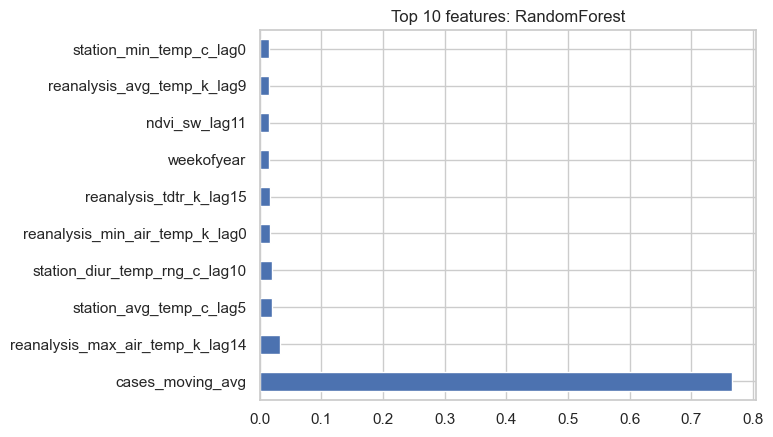

MAE with weather: 5.0416
MAE without weather: 5.2180
Weather improves MAE by: 0.1763

XGBoost — San Juan parameters: {'n_estimators': 413, 'max_depth': 7, 'learning_rate': 0.05495920515209877, 'subsample': 0.6773177288914334}
XGBoost — Iquitos parameters: {'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.0768245970859618, 'subsample': 0.7043155641521527}


In [14]:
# Prepare model inputs (15 best lagged features)
sj_input = prepare_model_input(sj_data, best_lags_sj, n_top_features=15)
iq_input = prepare_model_input(iq_data, best_lags_iq, n_top_features=15)

# --- Tuning and evaluation (both cities) ---
sj_tune = train_and_tune_city(sj_input, "SAN JUAN", optuna_trials=50)
iq_tune = train_and_tune_city(iq_input, "IQUITOS", optuna_trials=50)

# Results for plots, horizons, SHAP
models_sj, params_sj = sj_tune['models'], sj_tune['params']
models_iq, params_iq = iq_tune['models'], iq_tune['params']
X_tr_sj, y_tr_sj, X_te_sj, y_te_sj = sj_tune['X_train'], sj_tune['y_train'], sj_tune['X_test'], sj_tune['y_test']
X_tr_iq, y_tr_iq, X_te_iq, y_te_iq = iq_tune['X_train'], iq_tune['y_train'], iq_tune['X_test'], iq_tune['y_test']

best_xgb_sj = models_sj['XGBoost']
best_xgb_iq = models_iq['XGBoost']

print("\nXGBoost — San Juan parameters:", params_sj['XGBoost'])
print("XGBoost — Iquitos parameters:", params_iq['XGBoost'])


### Feature importance for the article (XGBoost)

After Optuna, **Random Forest** had the lowest test MAE for Iquitos (~5.01 vs ~5.13 for XGBoost). We still use **tuned XGBoost** in all final plots, horizon tests, and SHAP because:

- **San Juan** already wins with XGBoost — one algorithm for both cities keeps the story clear.
- The IQ gap is **small** (~2% relative MAE); rankings are sensitive to the single chronological split.
- **SHAP and Plotly sections** are built around XGBoost; mixing RF for IQ only would confuse readers.

The cell below prints the Optuna MAE table for Iquitos and draws **Top 10 feature importance for XGBoost** (SJ + IQ) — use these for Medium (`04_importance_sj.png`, `05_importance_iq.png`), not the auto-generated RF chart from `run_post_analysis`.

Iquitos — test MAE after Optuna (20% hold-out, lower is better):
RandomForest    5.041643
LightGBM        5.068764
XGBoost         5.109483

Using XGBoost for final analysis (MAE 5.1095) vs best RandomForest (5.0416).
Saved: 05_importance_iq.png


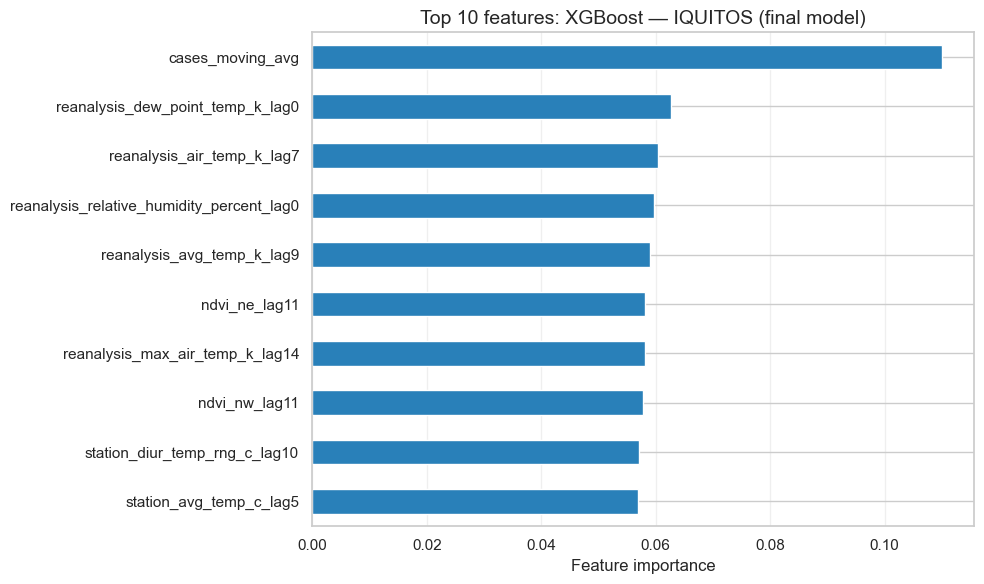

Saved: 04_importance_sj.png


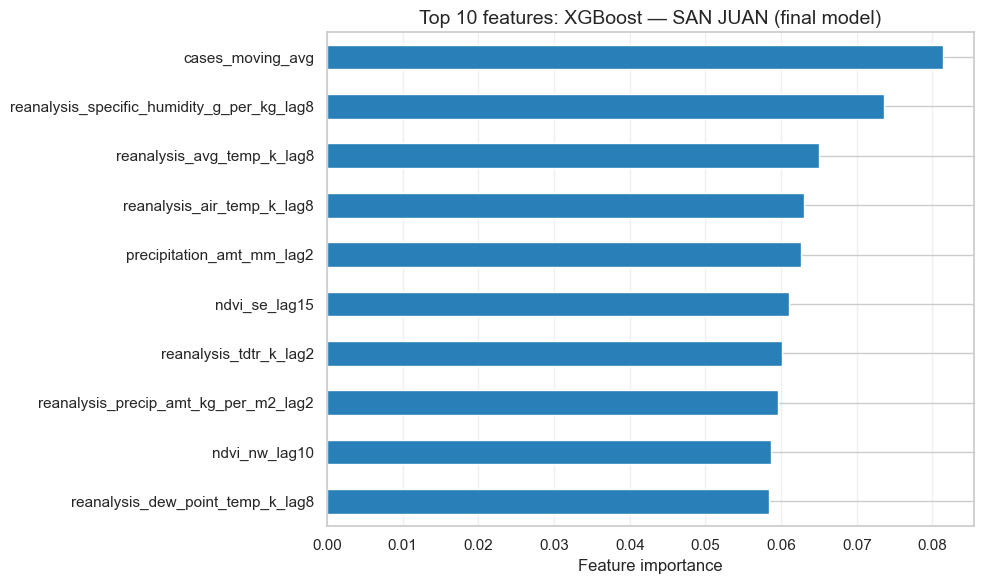

In [17]:
def plot_top10_features(model, feature_names, title, save_path=None):
    """Horizontal bar chart of top-10 feature importances (for report / Medium)."""
    top = (
        pd.Series(model.feature_importances_, index=feature_names)
        .nlargest(10)
        .sort_values()
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    top.plot(kind='barh', ax=ax, color='#2980b9')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Feature importance')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

# --- Iquitos: why XGBoost in the article when RF won Optuna? ---
iq_mae = {
    name: mean_absolute_error(y_te_iq, np.expm1(m.predict(X_te_iq)))
    for name, m in models_iq.items()
}
print("Iquitos — test MAE after Optuna (20% hold-out, lower is better):")
print(pd.Series(iq_mae).sort_values().to_string())
print(
    f"\nUsing XGBoost for final analysis (MAE {iq_mae['XGBoost']:.4f}) "
    f"vs best RandomForest ({iq_mae['RandomForest']:.4f})."
)

# XGBoost already fitted on 80% train during Optuna (same as SHAP / Plotly)
plot_top10_features(
    best_xgb_iq,
    X_tr_iq.columns,
    'Top 10 features: XGBoost — IQUITOS (final model)',
    save_path='05_importance_iq.png',
)

plot_top10_features(
    best_xgb_sj,
    X_tr_sj.columns,
    'Top 10 features: XGBoost — SAN JUAN (final model)',
    save_path='04_importance_sj.png',
)

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_enhanced_results_plotly(df_input, model, city_name, is_log_target=True):
    split = int(len(df_input) * 0.8)
    train, test = df_input.iloc[:split], df_input.iloc[split:]

    X_train, y_train = train.drop('total_cases', axis=1), train['total_cases']
    X_test, y_test = test.drop('total_cases', axis=1), test['total_cases']

    if is_log_target:
        model.fit(X_train, np.log1p(y_train))
        preds = np.expm1(model.predict(X_test))
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    preds = np.maximum(preds, 0).astype(int)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    residuals = y_test - preds

    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True,
        row_heights=[0.75, 0.25], vertical_spacing=0.05
    )

    fig.add_trace(go.Scatter(
        x=test.index, y=y_test,
        mode='lines', name='Actual',
        line=dict(color='#2c3e50', width=2.5)
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=test.index, y=preds,
        mode='lines', name='Model prediction',
        line=dict(color='#e74c3c', width=2, dash='dash'),
        fill='tonexty',
        fillcolor='rgba(231, 76, 60, 0.1)'
    ), row=1, col=1)

    colors = ['#2980b9' if r > 0 else "#b03123" for r in residuals]
    fig.add_trace(go.Bar(
        x=test.index, y=residuals,
        marker_color=colors,
        name='Error (Actual - Prediction)',
        opacity=0.7
    ), row=2, col=1)

    fig.update_layout(
        title=dict(
            text=f'<b>Final Model Analysis for {city_name}</b><br><sup>MAE: {mae:.2f} | R²: {r2:.2f}</sup>',
            font=dict(size=20)
        ),
        hovermode='x unified',
        template='plotly_white',
        height=700,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    fig.update_yaxes(title_text='Case count', row=1, col=1)
    fig.update_yaxes(title_text='Difference (Error)', zeroline=True, zerolinecolor='black', zerolinewidth=2, row=2, col=1)
    fig.update_xaxes(title_text='Time index (weeks)', row=2, col=1)
    fig.show()

# Retrain on 80% for plotly charts (same split as tuning)
plot_enhanced_results_plotly(sj_input, build_xgb(params_sj['XGBoost']), "SAN JUAN (Tuned XGBoost)")
plot_enhanced_results_plotly(iq_input, build_xgb(params_iq['XGBoost']), "IQUITOS (Tuned XGBoost)")



In [23]:
def test_prediction_horizons(df_input, city_name, xgb_params, horizons=(1, 4, 8, 12)):
    print(f"\n--- FORECAST HORIZON ANALYSIS FOR: {city_name} ---")
    results = {}

    for h in horizons:
        df_horizon = df_input.copy()
        df_horizon['target_future'] = df_horizon['total_cases'].shift(-h)
        df_horizon = df_horizon.dropna()
        X = df_horizon.drop(['total_cases', 'target_future'], axis=1)
        y = np.log1p(df_horizon['target_future'])

        split = int(len(X) * 0.8)
        X_train, X_test = X.iloc[:split], X.iloc[split:]
        y_train, y_test = y.iloc[:split], y.iloc[split:]

        model = build_xgb(xgb_params)
        model.fit(X_train, y_train)
        preds = np.maximum(np.expm1(model.predict(X_test)), 0).astype(int)
        mae = mean_absolute_error(np.expm1(y_test), preds)
        results[f'+{h} tyg.'] = mae
        print(f"Horizon +{h} weeks | MAE: {mae:.2f}")

    return results

horizon_sj = test_prediction_horizons(sj_input, "SAN JUAN", params_sj['XGBoost'])
horizon_iq = test_prediction_horizons(iq_input, "IQUITOS", params_iq['XGBoost'])




--- FORECAST HORIZON ANALYSIS FOR: SAN JUAN ---
Horizon +1 weeks | MAE: 11.01
Horizon +4 weeks | MAE: 13.27
Horizon +8 weeks | MAE: 16.59
Horizon +12 weeks | MAE: 16.93

--- FORECAST HORIZON ANALYSIS FOR: IQUITOS ---
Horizon +1 weeks | MAE: 5.38
Horizon +4 weeks | MAE: 6.07
Horizon +8 weeks | MAE: 7.01
Horizon +12 weeks | MAE: 7.31


Forecast horizon analysis shows stable short-term accuracy (1–4 weeks), but error grows substantially beyond ~2 months (+8 weeks).


In [24]:
import plotly.express as px
import pandas as pd

def plot_interactive_horizons(results_dict, city_name):
    # 1. Convert results dict to DataFrame
    df_plot = pd.DataFrame({
        'Horizon': list(results_dict.keys()),
        'MAE': list(results_dict.values())
    })
    
    # 2. Interactive bar chart
    fig = px.bar(
        df_plot, 
        x='Horizon', 
        y='MAE',
        text='MAE', # Show exact values on bars
        title=f'<b>Model Degradation Over Time: {city_name}</b><br><sup>MAE error growth by forecast horizon</sup>',
        labels={'Horizon': 'Forecast horizon', 'MAE': 'MAE error (lower is better)'},
        color='MAE', # Color by error magnitude
        color_continuous_scale='Reds' # White-to-red scale
    )
    
    # 3. Layout styling
    fig.update_traces(
        texttemplate='<b>%{text:.2f}</b>', 
        textposition='outside',
        marker_line_color='black', 
        marker_line_width=1.5
    )
    
    fig.update_layout(
        template='plotly_white',
        xaxis=dict(showgrid=False),
        yaxis=dict(showgrid=True, gridcolor='lightgray'),
        coloraxis_showscale=False, # Hide color scale for cleaner look
        height=500
    )
    
    fig.show()


plot_interactive_horizons(horizon_iq, "IQUITOS")
plot_interactive_horizons(horizon_sj, "SAN JUAN")


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.preprocessing import StandardScaler

def train_neural_network(df_input, city_name):
    print(f"--- TRAINING NEURAL NETWORK: {city_name} ---")
    
    # 1. Prepare data
    split = int(len(df_input) * 0.8)
    train, test = df_input.iloc[:split], df_input.iloc[split:]
    
    X_train = train.drop('total_cases', axis=1)
    y_train = np.log1p(train['total_cases'])  # log transform helps regression
    X_test = test.drop('total_cases', axis=1)
    y_test = test['total_cases']

    # 2. SCALING (critical for neural nets)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. NETWORK ARCHITECTURE
    model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),                 # stronger regularization
    Dense(64, activation='leaky_relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

# Adam optimizer with learning rate
    from tensorflow.keras.optimizers import Adam
    optimizer = Adam(learning_rate=0.0001) 
    model.compile(optimizer=optimizer, loss='mae')

    from tensorflow.keras.callbacks import EarlyStopping
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    

    # 4. TRAINING
    model.fit(
        X_train_scaled, y_train,
        validation_split=0.2, # validation split
        epochs=300,            # more epochs, slower learning
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    # 5. PREDICTION AND EVALUATION
    preds_log = model.predict(X_test_scaled)
    preds = np.expm1(preds_log).flatten()
    preds = np.maximum(preds, 0).astype(int)
    
    mae = mean_absolute_error(y_test, preds)
    print(f"Neural network MAE for {city_name}: {mae:.2f}")
    
    return model, scaler, preds

nn_model_iq, nn_scaler_iq, nn_preds_iq = train_neural_network(iq_input, "IQUITOS")
nn_model_sj, nn_scaler_sj, nn_preds_sj = train_neural_network(sj_input, "SAN JUAN")


--- TRAINING NEURAL NETWORK: IQUITOS ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Neural network MAE for IQUITOS: 7.23
--- TRAINING NEURAL NETWORK: SAN JUAN ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Neural network MAE for SAN JUAN: 21.50


On this small, noisy epidemiological dataset, tree-based models generalized much better than neural networks, which tended to overfit despite regularization.


--- RUNNING CHRONOS MODEL FOR: SAN JUAN ---
Loading Chronos model on: CPU


`torch_dtype` is deprecated! Use `dtype` instead!


Model running... (first run downloads weights from Hugging Face)
Chronos model MAE for SAN JUAN: 28.54


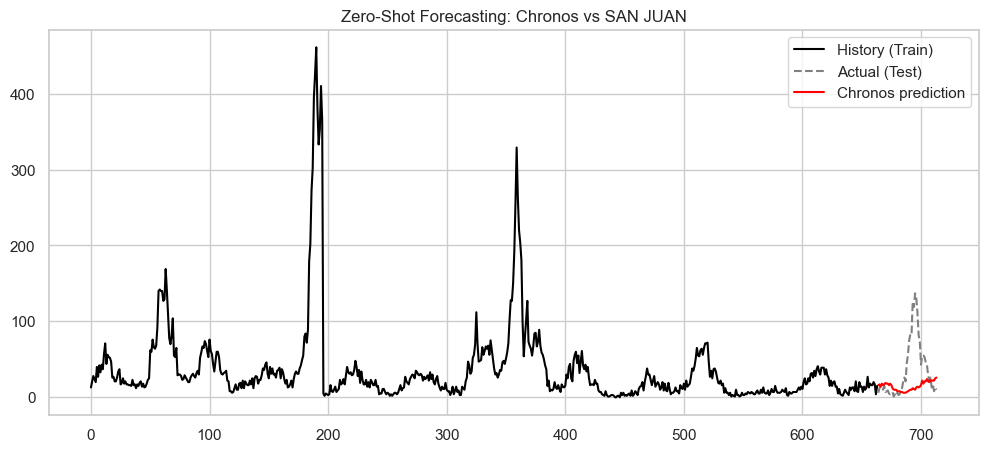

--- RUNNING CHRONOS MODEL FOR: IQUITOS ---
Loading Chronos model on: CPU
Model running... (first run downloads weights from Hugging Face)
Chronos model MAE for IQUITOS: 8.68


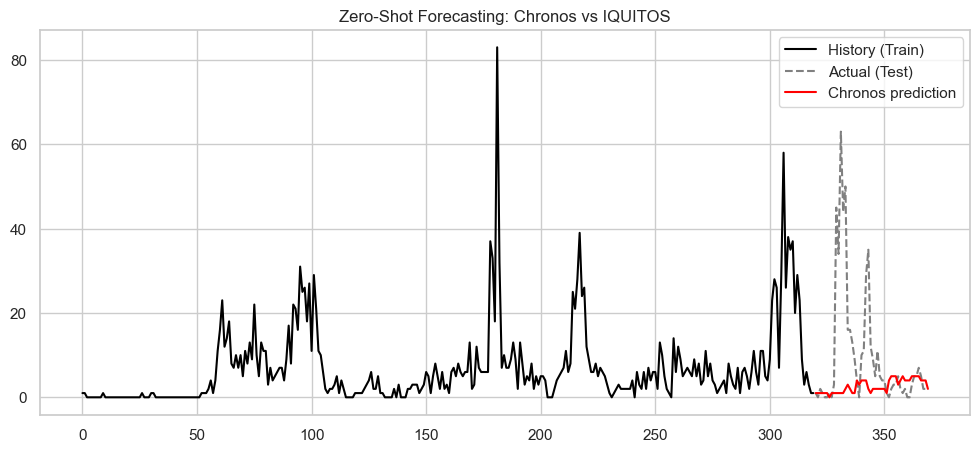

8.68

In [18]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

def load_chronos_pipeline(model_id="amazon/chronos-t5-tiny"):
    """Amazon Chronos (chronos-forecasting).

    In chronos-forecasting >= 2.x, import from chronos.chronos or BaseChronosPipeline.
    """
    from chronos import ChronosPipeline

    # Prefer MPS on Apple Silicon when available
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"Loading Chronos model on: {device.upper()}")

    return ChronosPipeline.from_pretrained(
        model_id,
        device_map=device,
        torch_dtype=torch.float32,
    )

def run_chronos_forecast(df_input, city_name, prediction_length=50):
    print(f"--- RUNNING CHRONOS MODEL FOR: {city_name} ---")

    try:
        pipeline = load_chronos_pipeline("amazon/chronos-t5-tiny")
    except Exception as exc:
        print("Failed to load Chronos:", exc)
        print("Try: pip uninstall chronos -y && pip install chronos-forecasting")
        return None

    split = int(len(df_input) * 0.8)
    train_data = df_input.iloc[:split]['total_cases'].values.astype(np.float32)
    test_data = df_input.iloc[split:]['total_cases'].values
    pred_len = min(prediction_length, len(test_data))

    context = torch.tensor(train_data, dtype=torch.float32)
    print("Model running... (first run downloads weights from Hugging Face)")

    forecast = pipeline.predict(context, prediction_length=pred_len, num_samples=20)
    if isinstance(forecast, torch.Tensor):
        forecast_median = forecast.median(dim=1).values.squeeze(0).numpy()
    else:
        forecast_median = np.quantile(np.asarray(forecast)[0], 0.5, axis=0)

    forecast_median = np.maximum(forecast_median, 0).astype(int)
    mae = mean_absolute_error(test_data[:pred_len], forecast_median)
    print(f"Chronos model MAE for {city_name}: {mae:.2f}")

    plt.figure(figsize=(12, 5))
    plt.plot(range(len(train_data)), train_data, color="black", label="History (Train)")
    x_test = range(len(train_data), len(train_data) + pred_len)
    plt.plot(x_test, test_data[:pred_len], color="gray", linestyle="--", label="Actual (Test)")
    plt.plot(x_test, forecast_median, color="red", label="Chronos prediction")
    plt.title(f"Zero-Shot Forecasting: Chronos vs {city_name}")
    plt.legend()
    plt.show()
    return mae

run_chronos_forecast(sj_input, "SAN JUAN", prediction_length=50)
run_chronos_forecast(iq_input, "IQUITOS", prediction_length=50)


Chronos-T5 (zero-shot) underperformed (MAE ~28.3 for SJ, ~8.7 for IQ) and missed sudden surges—case history alone is insufficient; weather and environmental features help tree models much more.


TimesFM was skipped due to JAX/Paxml/lingvo build issues on Python 3.12 / Windows. Amazon Chronos-T5 was used instead as the zero-shot foundation-model baseline.


--- SHAP (XAI) ANALYSIS FOR: IQUITOS (XGBoost) ---



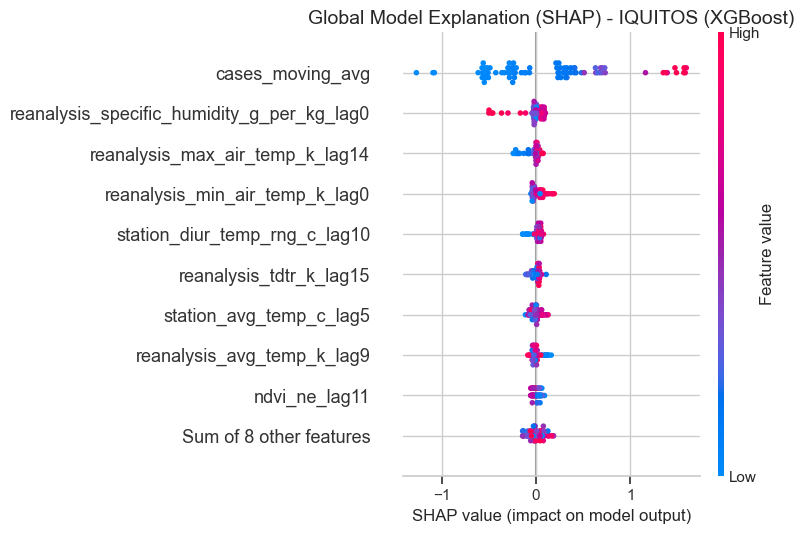


Why did the model predict an epidemic peak at index 331?


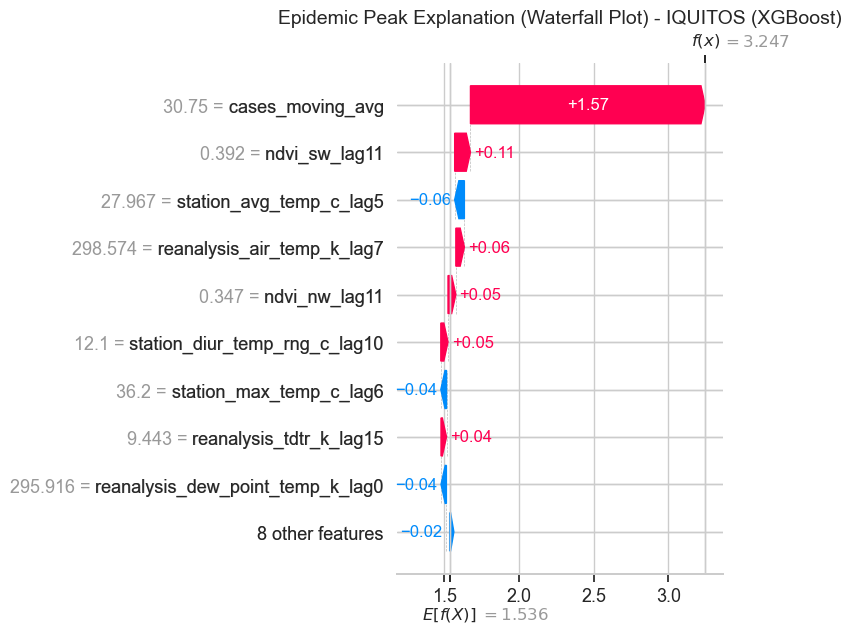

--- SHAP (XAI) ANALYSIS FOR: SAN JUAN (XGBoost) ---


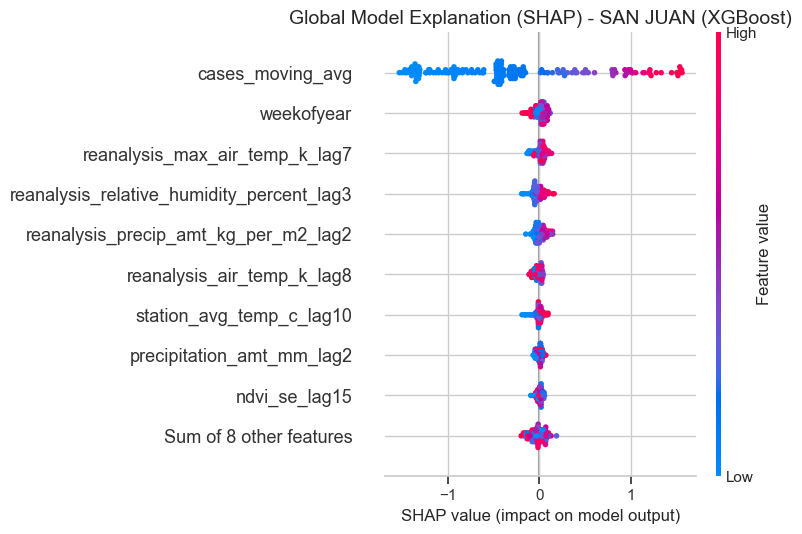


Why did the model predict an epidemic peak at index 697?


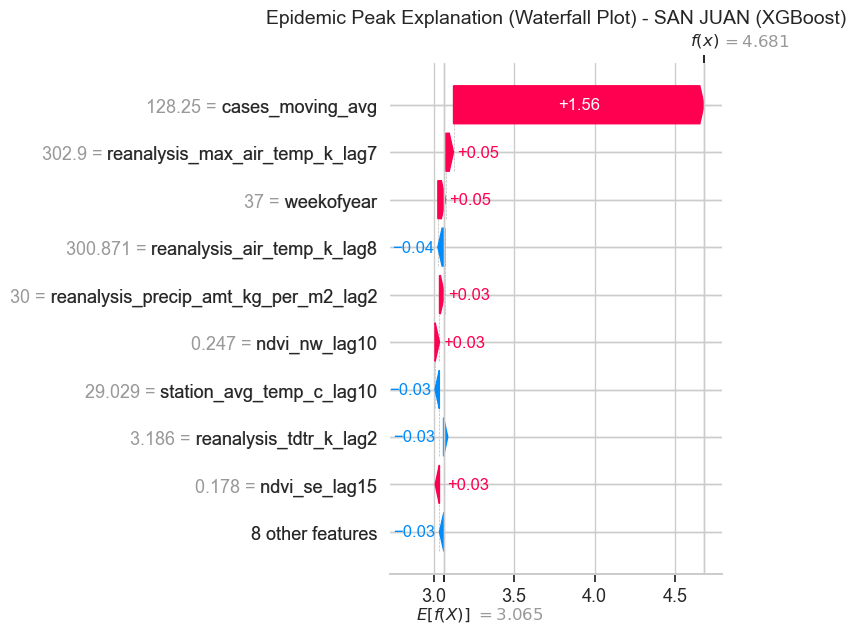

In [19]:
import shap

def run_shap_analysis(model, X_test_df, city_name):
    print(f"--- SHAP (XAI) ANALYSIS FOR: {city_name} ---")
    explainer = shap.Explainer(model)
    shap_values = explainer(X_test_df)

    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_values, max_display=10, show=False)
    plt.title(f"Global Model Explanation (SHAP) - {city_name}", fontsize=14)
    plt.xlabel("SHAP value (impact on model output)", fontsize=12)
    fig = plt.gcf()
    for ax in fig.axes:
        if ax.get_ylabel() == 'Feature value':
            ax.set_ylabel('Feature value', fontsize=12)
    plt.tight_layout()
    plt.show()

    predictions = model.predict(X_test_df)
    max_idx = predictions.argmax()
    print(f"\nWhy did the model predict an epidemic peak at index {X_test_df.index[max_idx]}?")

    plt.figure(figsize=(10, 6))
    plt.title(f"Epidemic Peak Explanation (Waterfall Plot) - {city_name}", fontsize=14)
    shap.plots.waterfall(shap_values[max_idx], max_display=10, show=False)
    plt.tight_layout()
    plt.show()

split_iq = int(len(iq_input) * 0.8)
X_test_iq = iq_input.iloc[split_iq:].drop('total_cases', axis=1)
run_shap_analysis(best_xgb_iq, X_test_iq, "IQUITOS (XGBoost)")

split_sj = int(len(sj_input) * 0.8)
X_test_sj = sj_input.iloc[split_sj:].drop('total_cases', axis=1)
run_shap_analysis(best_xgb_sj, X_test_sj, "SAN JUAN (XGBoost)")



SHAP analysis shows epidemic momentum (lagged moving average of cases) as the top driver in both cities, plus seasonality and lagged weather—not same-week weather. San Juan reacts more to rainfall and max temperature spikes; Iquitos to vegetation indices and minimum temperature. Tuned XGBoost with lag engineering yields interpretable, epidemiologically plausible forecasts.
